# Apartment Data Cleaning Workflow
This notebook cleans apartment listing data through profiling, missing-value handling, outlier treatment, and final export.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
print(pd.__version__)

# Set display options for better readability
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100) 

print("Libraries imported successfully!")

2.3.0
Libraries imported successfully!


## Load Dataset and Perform Initial Inspection
Read the apartment dataset and review its shape, schema, and sample rows to confirm basic integrity.

In [ ]:
df = pd.read_csv('../../data/apartment/satilir_properties_apartment.csv')
print("Data loaded successfully!")

print("Dataset shape:", df.shape)

print("Number of observations:", df.shape[0])

print("Number of features:", df.shape[1])

Data loaded successfully!
Dataset shape: (4987, 24)
Number of observations: 4987
Number of features: 24


In [83]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4987 entries, 0 to 4986
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   price                     4987 non-null   int64  
 1   rooms                     4986 non-null   float64
 2   area_m2                   4987 non-null   float64
 3   floor                     4986 non-null   float64
 4   has_document              4987 non-null   object 
 5   address                   4987 non-null   object 
 6   avtodayanacaq             4987 non-null   object 
 7   balkon                    4987 non-null   object 
 8   duzelme                   4987 non-null   object 
 9   esyali                    4987 non-null   object 
 10  hovuz                     4987 non-null   object 
 11  internet                  4987 non-null   object 
 12  isiq                      4987 non-null   object 
 13  kabel_tv                  4987 non-null   object 
 14  kombi   

In [84]:
df.head()

,price,rooms,area_m2,floor,has_document,address,avtodayanacaq,balkon,duzelme,esyali,hovuz,internet,isiq,kabel_tv,kombi,kondisioner,lift,merkezi_qizdirici_sistem,metbex_mebeli,pvc_pencere,qaz,su,telefon,temirsiz
0,200000,3.0,65.0,5.0,No,"Bakı, Nərimanov, metro 28 May",Yes,Yes,No,No,No,Yes,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,No,No
1,800000,4.0,197.0,9.0,Yes,"Bakı, Nərimanov, metro Gənclik",Yes,Yes,No,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,No
2,210000,2.0,54.0,12.0,No,"Bakı, Nərimanov, metro Nəriman Nərimanov",No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No
3,149000,4.0,100.0,2.0,Yes,"Bakı, Binəqədi, Biləcəri qəs.",No,No,No,Yes,No,No,No,No,No,No,No,No,No,No,No,No,No,No
4,45000,1.0,44.0,1.0,Yes,Xırdalan,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No


## Detect and Remove Duplicate Rows
Measure duplicate records, inspect them, remove exact duplicates, and compare dataset size before versus after deduplication.

In [85]:
print(df.duplicated().sum())

199


In [86]:
dup_rows = df[df.duplicated(keep=False)]  
dup_rows.sort_index()  

,price,rooms,area_m2,floor,has_document,address,avtodayanacaq,balkon,duzelme,esyali,hovuz,internet,isiq,kabel_tv,kombi,kondisioner,lift,merkezi_qizdirici_sistem,metbex_mebeli,pvc_pencere,qaz,su,telefon,temirsiz
56,115000,3.0,75.0,2.0,Yes,"Bakı, Abşeron, Masazır",Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,No,No,Yes,Yes,Yes,No,Yes,Yes,No
87,10000,2.0,50.0,1.0,Yes,"Bakı, Abşeron, Masazır",Yes,No,No,No,No,Yes,Yes,No,No,No,No,No,Yes,Yes,Yes,Yes,No,No
88,10000,2.0,50.0,1.0,Yes,"Bakı, Abşeron, Masazır",Yes,No,No,No,No,Yes,Yes,No,No,No,No,No,Yes,Yes,Yes,Yes,No,No
89,10000,2.0,50.0,1.0,Yes,"Bakı, Abşeron, Masazır",Yes,No,No,No,No,Yes,Yes,No,No,No,No,No,Yes,Yes,Yes,Yes,Yes,No
139,39000,2.0,58.0,11.0,Yes,Xırdalan,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4874,65000,2.0,38.0,5.0,Yes,"Bakı, Abşeron, Masazır",No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No
4884,130000,2.0,55.0,2.0,No,"Bakı, Xətai, Əhmədli, metro Həzi Aslanov",No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No
4904,368000,3.0,100.0,13.0,Yes,"Bakı, Nərimanov, metro Nəriman Nərimanov",No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No
4934,65000,2.0,65.0,12.0,Yes,"Bakı, Binəqədi, 7-ci mikrorayon, metro Dərnəgül",No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No


In [87]:
df_2 = df.drop_duplicates(keep="first").reset_index(drop=True)

In [88]:
print("Previous dataset shape:", df.shape)
print("Duplicates removed. New dataset shape:", df_2.shape)
print("Number of duplicates removed:", df.shape[0] - df_2.shape[0])

Previous dataset shape: (4987, 24)
Duplicates removed. New dataset shape: (4788, 24)
Number of duplicates removed: 199


## Profile Feature Types
Separate columns into numeric and categorical groups to guide cleaning strategy and later analysis.

In [89]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("Number of numerical columns:", len(num_cols))
print("Numerical columns:", num_cols)

Number of numerical columns: 4
Numerical columns: ['price', 'rooms', 'area_m2', 'floor']


In [90]:
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
print("Number of categorical columns:", len(cat_cols))
print("Categorical columns:", cat_cols)

Number of categorical columns: 20
Categorical columns: ['has_document', 'address', 'avtodayanacaq', 'balkon', 'duzelme', 'esyali', 'hovuz', 'internet', 'isiq', 'kabel_tv', 'kombi', 'kondisioner', 'lift', 'merkezi_qizdirici_sistem', 'metbex_mebeli', 'pvc_pencere', 'qaz', 'su', 'telefon', 'temirsiz']


## Analyze Missing Values and Investigate Problematic Records
Create a reusable missing-value summary, clone the dataset for cleaning, and inspect rows that need targeted fixes.

In [91]:
def df_missing_values_summary(df):
    mis_values = df.isnull().sum()
    mis_percent = (mis_values / len(df)) * 100

    df_mis = pd.DataFrame({
        "Column": df.columns,
        "Missing Values": mis_values,
        "Percentage": mis_percent
    })

    df_mis = df_mis[df_mis["Missing Values"] > 0].sort_values(by="Percentage", ascending=False).reset_index(drop=True)
    return df_mis

In [92]:
df_mis = df_missing_values_summary(df)
print("Missing values summary:")
print("Number of columns with missing values:", df_mis.shape[0])
df_mis

Missing values summary:
Number of columns with missing values: 2


,Column,Missing Values,Percentage
0,rooms,1,0.020052
1,floor,1,0.020052


In [93]:
df_clean = df.copy()

In [94]:
df_clean.loc[df_clean["rooms"].isnull()]

,price,rooms,area_m2,floor,has_document,address,avtodayanacaq,balkon,duzelme,esyali,hovuz,internet,isiq,kabel_tv,kombi,kondisioner,lift,merkezi_qizdirici_sistem,metbex_mebeli,pvc_pencere,qaz,su,telefon,temirsiz
822,35000,NaN,16.0,NaN,No,"Bakı, Qaradağ, Lökbatan qəs.",No,No,No,No,No,No,Yes,No,No,No,No,No,No,No,No,Yes,No,No


In [95]:
df_clean.query(" 10 <= area_m2 <= 20")

,price,rooms,area_m2,floor,has_document,address,avtodayanacaq,balkon,duzelme,esyali,hovuz,internet,isiq,kabel_tv,kombi,kondisioner,lift,merkezi_qizdirici_sistem,metbex_mebeli,pvc_pencere,qaz,su,telefon,temirsiz
617,37000,1.0,20.0,21.0,Yes,"Bakı, Binəqədi, 8-ci mikrorayon, metro Azadlıq",No,No,No,Yes,No,Yes,Yes,Yes,No,Yes,Yes,No,Yes,Yes,Yes,Yes,No,No
822,35000,NaN,16.0,NaN,No,"Bakı, Qaradağ, Lökbatan qəs.",No,No,No,No,No,No,Yes,No,No,No,No,No,No,No,No,Yes,No,No
2747,88000,1.0,20.0,2.0,Yes,"Bakı, Nəsimi",Yes,Yes,No,Yes,No,Yes,Yes,Yes,Yes,Yes,No,No,Yes,Yes,Yes,Yes,Yes,No
2904,25000,1.0,20.0,2.0,Yes,"Sumqayıt, 12-ci mikrorayon",No,Yes,No,No,No,No,Yes,Yes,No,No,No,No,No,Yes,Yes,Yes,Yes,No


## Apply Targeted Data Fixes and Recheck Missingness
Patch known anomalies in rooms and floor, then recompute missing-value statistics to validate improvements.

In [96]:
df_clean.loc[(df_clean["area_m2"] == 16) & (df_clean["rooms"].isnull()), "rooms"] = 1
df_clean.loc[(df_clean["area_m2"] == 16) & (df_clean["floor"].isnull()), "floor"] = 1


In [97]:
df_mis_2 = df_missing_values_summary(df_clean)
print("Missing values summary:")
print("Number of columns with missing values:", df_mis_2.shape[0])
df_mis_2

Missing values summary:
Number of columns with missing values: 0


,Column,Missing Values,Percentage


## Explore Numeric Distributions and Handle Major Price Outlier
Visualize key numeric features, inspect price spread, remove the extreme price value, and compare distributions.

In [98]:
def plot_numeric_distributions(df, numeric_cols):
    key_numeric_features = [col for col in numeric_cols if col in df.columns]

    fig, axes = plt.subplots(len(key_numeric_features), 1, figsize=(5, 4*len(key_numeric_features)))

    if len(key_numeric_features) == 1:
        axes = [axes]
    for i, col in enumerate(key_numeric_features):
        axes[i].boxplot(df[col].dropna(), vert=False)
        axes[i].set_ylabel(col)
        axes[i].set_title(f"Box Plot of {col}")
    plt.tight_layout()
    plt.show()

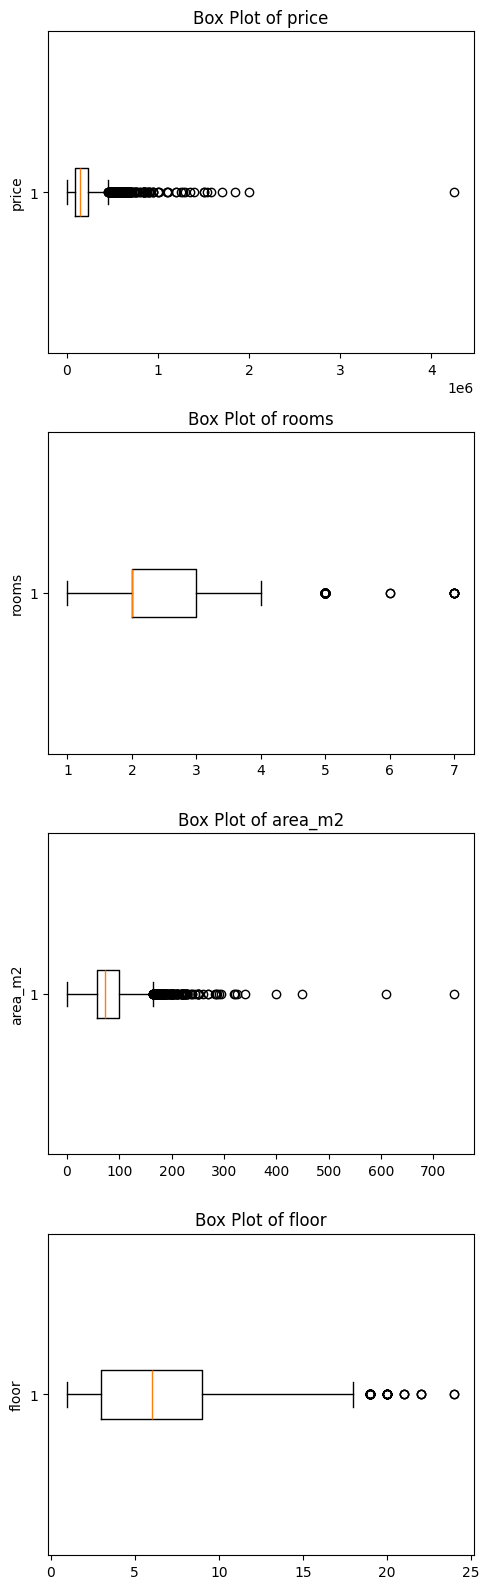

In [99]:
key_numeric_features = ['price', 'rooms', 'area_m2', 'floor']
plot_numeric_distributions(df_clean, key_numeric_features)

In [100]:
df_clean['price'].describe()

count    4.987000e+03
mean     1.831034e+05
std      1.621614e+05
min      7.300000e+03
25%      8.800000e+04
50%      1.490000e+05
75%      2.330000e+05
max      4.250000e+06
Name: price, dtype: float64

In [101]:
df_clean.drop(df_clean[df_clean['price'] == 4250000].index, inplace=True)
df_clean['price'].describe()

count    4.986000e+03
mean     1.822877e+05
std      1.516016e+05
min      7.300000e+03
25%      8.800000e+04
50%      1.490000e+05
75%      2.327500e+05
max      2.000000e+06
Name: price, dtype: float64

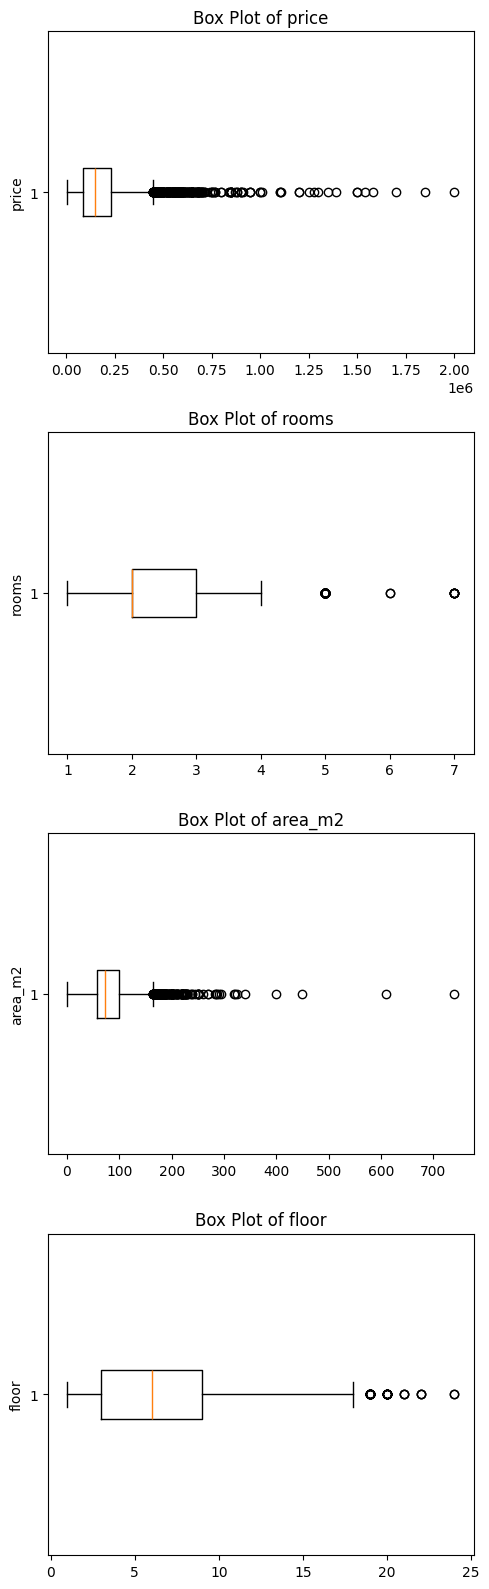

In [102]:
plot_numeric_distributions(df_clean, key_numeric_features)

In [103]:
def IQR_finding_outliers(df,column):
    Q1 = np.percentile(df[column].dropna(),25)
    Q3 = np.percentile(df[column].dropna(),75)
    IQR = Q3 - Q1 
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers, lower_bound ,upper_bound

for col in key_numeric_features:
    outliers, lower_bound, upper_bound = IQR_finding_outliers(df_clean, col)
    print(f"Column: {col}")
    print(f"Lower Bound: {lower_bound}, Upper Bound: {upper_bound}")
    print(f"Number of outliers found: {outliers.shape[0]}\n")
    

Column: price
Lower Bound: -129125.0, Upper Bound: 449875.0
Number of outliers found: 252

Column: rooms
Lower Bound: 0.5, Upper Bound: 4.5
Number of outliers found: 92

Column: area_m2
Lower Bound: -7.5, Upper Bound: 164.5
Number of outliers found: 187

Column: floor
Lower Bound: -6.0, Upper Bound: 18.0
Number of outliers found: 50



## Detect and Filter Outliers with the IQR Method
Estimate per-feature outlier bounds, remove outliers, and compare dataset size before and after filtering.

In [104]:
for col in key_numeric_features:
    outliers, lower_bound, upper_bound = IQR_finding_outliers(df_clean, col)
    df_clean_2 = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]


In [107]:
print("Before outlier removal:", df_clean.shape)
print("After outlier removal:", df_clean_2.shape)
print("Outliers removed:", df_clean.shape[0] - df_clean_2.shape[0])

Before outlier removal: (4986, 24)
After outlier removal: (4936, 24)
Outliers removed: 50


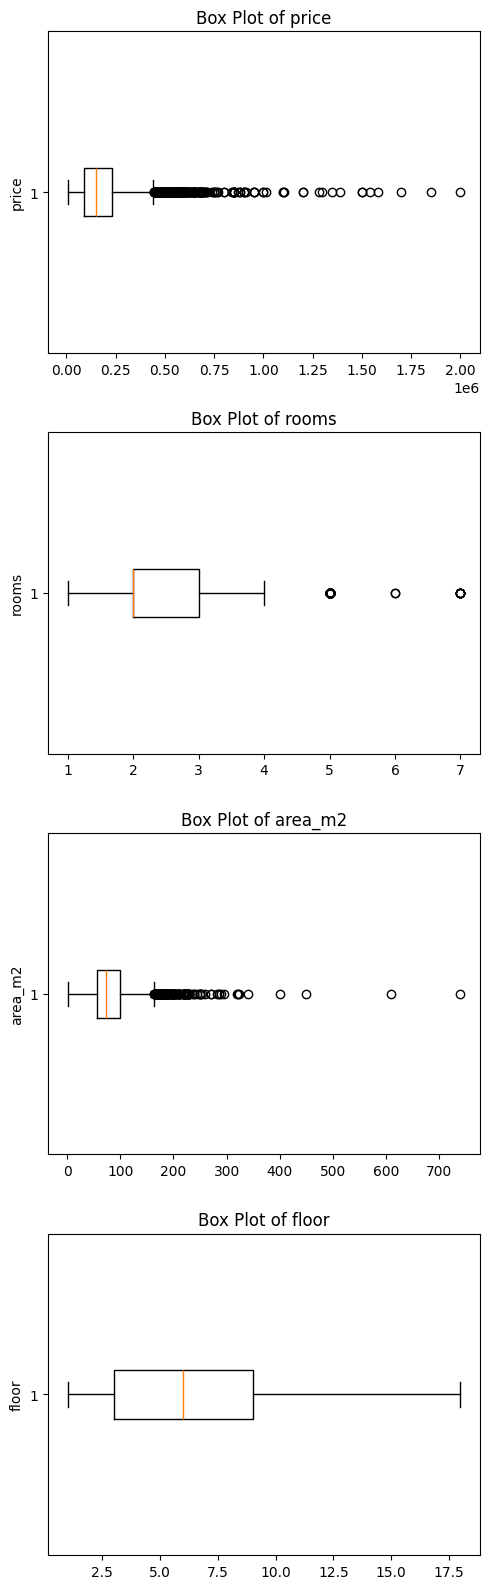

In [108]:
plot_numeric_distributions(df_clean_2, key_numeric_features)

## Summarize Cleaning Results and Export Final Dataset
Report final data quality metrics and save the cleaned apartment dataset for downstream modeling.

In [109]:
print(f"Original dataset shape: {df.shape}")
print(f"Cleaned dataset shape: {df_clean_2.shape}")
# - Number of rows removed
print(f"Number of rows removed: {df.shape[0] - df_clean_2.shape[0]}")
# - Number of columns removed
print(f"Number of columns removed: {df.shape[1] - df_clean_2.shape[1]}")
# - Remaining missing values count
print(f"Remaining missing values count: {df_clean_2.isnull().sum().sum()}")
# - Data types value counts
print("Data types value counts:")
print(df_clean_2.dtypes.value_counts())

Original dataset shape: (4987, 24)
Cleaned dataset shape: (4936, 24)
Number of rows removed: 51
Number of columns removed: 0
Remaining missing values count: 0
Data types value counts:
object     20
float64     3
int64       1
Name: count, dtype: int64


In [111]:
df_clean_2.to_csv('../../data/apartment/satilir_properties_apartment_cleaned.csv', index=False)
print("Cleaned dataset saved to 'data/apartment/satilir_properties_apartment_cleaned.csv'")

Cleaned dataset saved to 'data/apartment/satilir_properties_apartment_cleaned.csv'
